# Simple model with Flow Matching

Attempting to do the same thing as in `simple_model.ipynb`, but using Flow Matching instead of MCMC sampling. 

In [31]:
from typing import Optional, List, Type, Tuple, Dict

import sys
sys.path.append('..')

from src.simulator import BurstSimulator, Model
from src.flow_matching.probability_path import Sampleable, LinearConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer, MLPVectorField
from src.flow_matching.integration import LearnedVectorFieldODE, EulerODESolver

import numpy as np
import matplotlib.cm as cm
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [32]:
# Several plotting utility functions
def hist2d_samples(samples, bins: int = 200, percentile: int = 99, **kwargs):
    H, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins)

    # Determine color normalization based on the 99th percentile
    cmax = np.percentile(H, percentile)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

    # Plot using imshow for more control
    plt.imshow(H.T, origin='lower', norm=norm, **kwargs)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

# Example from MIT Lab two

Modified example from the MIT course where they transform an isotropic Gaussian into an arbitrary distribution using a linear conditional probability path. 

In [33]:
class Gaussian(torch.nn.Module, Sampleable):
    """
    Multivariate Gaussian distribution
    """
    def __init__(self, mean: torch.Tensor, cov: torch.Tensor):
        """
        mean: shape (dim,)
        cov: shape (dim,dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    @property
    def dim(self) -> int:
        return self.mean.shape[0]

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples) -> torch.Tensor:
        return self.distribution.sample((num_samples,))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

    @classmethod
    def isotropic(cls, dim: int, std: float) -> "Gaussian":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std ** 2
        return cls(mean, cov)
    
class CheckerboardSampleable(Sampleable):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]

In [4]:
# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Gaussian.isotropic(dim=2, std=1.0),
    p_data = CheckerboardSampleable(device, grid_size=4)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)


Training model with size: 0.049 MiB


Epoch 8, loss: 18.338: : 7it [00:00, 37.86it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([1.2179, 1.6878])


Epoch 999, loss: 8.824: : 1000it [00:17, 57.13it/s]


100%|██████████| 99/99 [00:04<00:00, 22.46it/s]


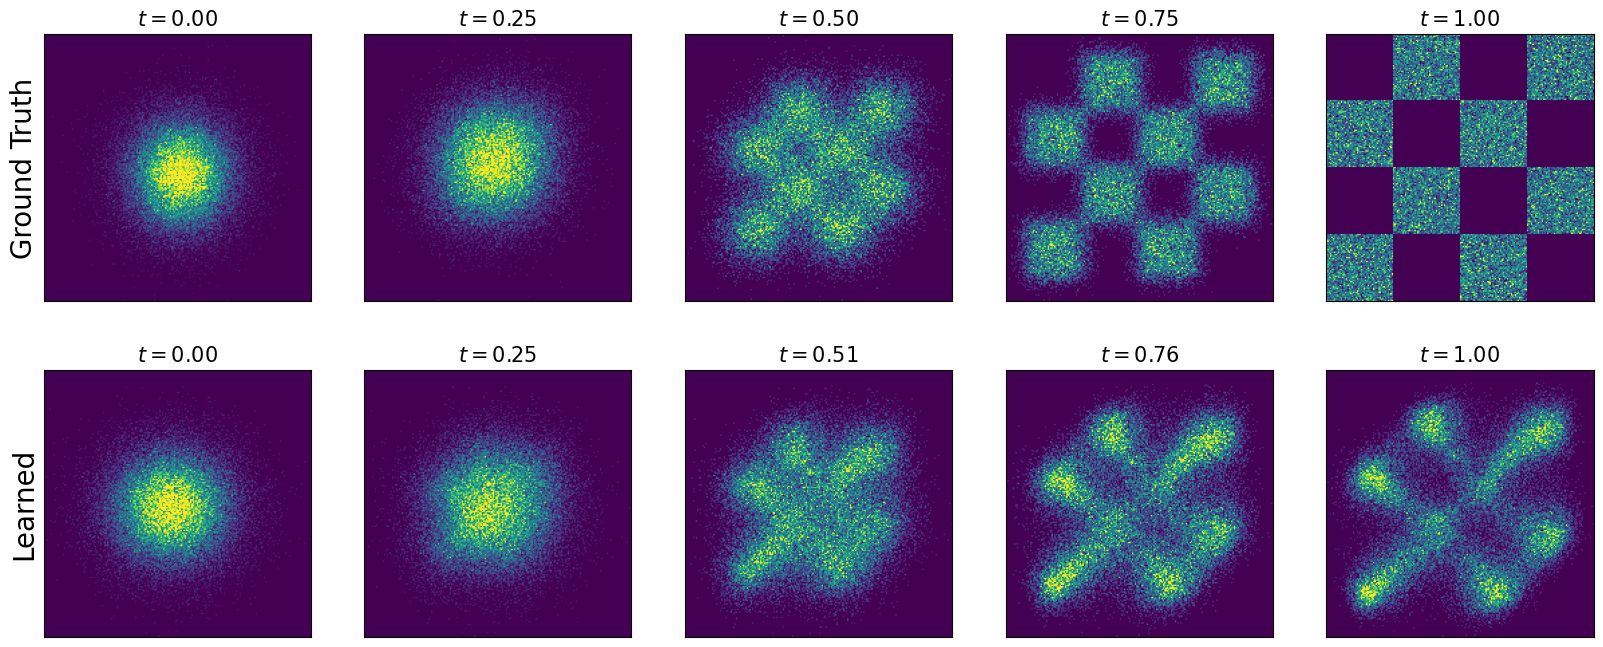

In [ ]:
num_marginals = 5    # number of snapshots to plot
num_samples = 50000  # number of samples per snapshot 

plt.figure(figsize=(20,8))

# -------------------------------------------- #
#        Plotting Ground-Truth Marginals       #
# -------------------------------------------- #

ts = torch.linspace(0.0, 1.0, num_marginals).to(device)

for idx, t in enumerate(ts):

    tt = t.view(1,1).expand(num_samples, 1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts)

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={t.item():.2f}$', fontsize=15)

    plt.ylabel("Ground Truth", fontsize=20) if idx == 0 else None

# -------------------------------------------- #
# Plotting Marginals of Learned Vector Field   #
# -------------------------------------------  #

# initialize ODE solver
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ODE from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# save only num_marginal snapshots of the trajectory
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

plot_idx = idx + 1

# plot the snapshots
for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]

    plt.subplot(2, num_marginals, plot_idx + idx + 1)
    hist2d_samples(xx)

    plt.xticks([])
    plt.yticks([])

    tt = ts[record_every_idxs[idx]]
    plt.title(f'$t={tt.item():.2f}$', fontsize=15)
    plt.ylabel("Learned", fontsize=20) if idx == 0 else None

plt.show()

# Example CFM for SBI

In [8]:
# Need to change 
# Samplelable prior for t0_1 and t0_2
class Prior(Sampleable):
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_samples, _ = torch.sort(torch.rand((num_samples, self.dim)), dim=1)
        return t0_samples.to(device)

# Samplelable posterior 
class Posterior(Sampleable):

    """
    This is now for a given datapoint, so just returns true_t0_1, true_t0_2
    """
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_1 = 0.1 * torch.ones((num_samples, 1))
        t0_2 = 0.6 * torch.ones((num_samples, 1))
        return torch.cat((t0_1, t0_2), dim=1)

# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),# should be Sampleable prior 
    p_data = Posterior() # this should be posterior sample (+ labels, i.e. simulated data, later on)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)

Training model with size: 0.049 MiB


0it [00:00, ?it/s]

Epoch 6, loss: 0.177: : 3it [00:00, 27.64it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([0.1000, 0.6000])


Epoch 999, loss: 0.005: : 1000it [00:16, 59.41it/s]


100%|██████████| 99/99 [00:00<00:00, 111.73it/s]


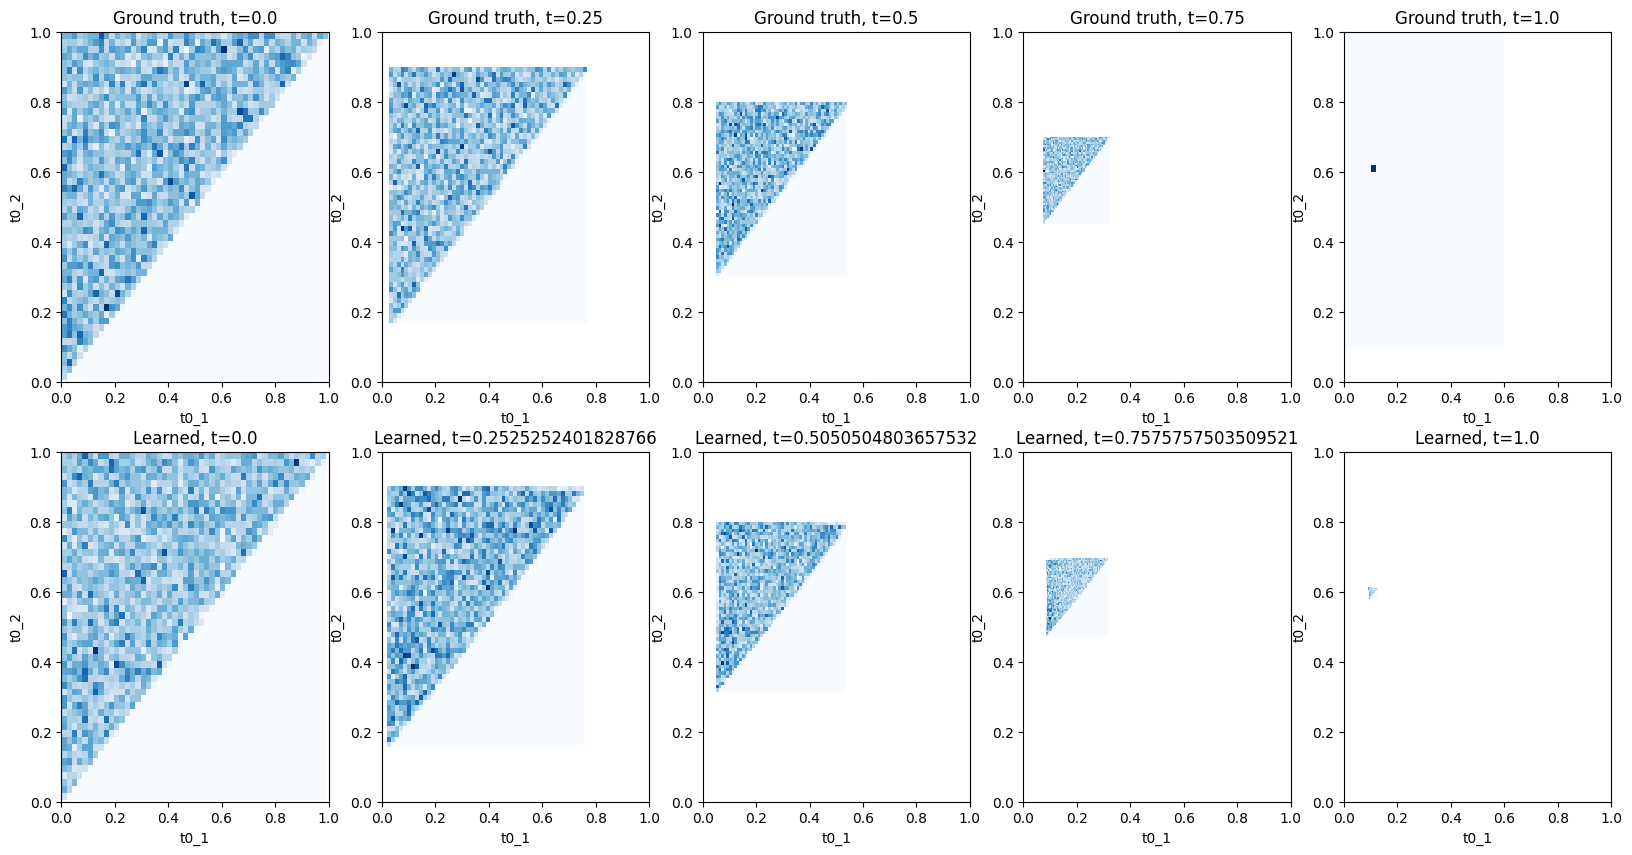

In [9]:
##########################
# Play around With These #
##########################
num_samples = 10000
num_marginals = 5

plt.figure(figsize=(20, 10))

###########################
# Graph Ground-Truth Marginals #
###########################
ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)
    t = tt.cpu()[0][0]

    plt.subplot(2, num_marginals, idx + 1)

    plt.hist2d(x=xts[:, 0], y=xts[:, 1], bins=50, cmap='Blues')

    plt.title(f"Ground truth, t={t}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0,1)

###############################################
# Graph Marginals of Learned Vector Field #
###############################################
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))
xts = xts[:,record_every_idxs,:]

subplot_idx = idx + 1 # for plotting 

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(2, num_marginals, subplot_idx + idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    
    plt.title(f"Learned, t={t}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# Adding guiding with simulated data for fixed parameters
Now want to do guided flow matching, meaning the transformation is guided by a sample from the simulated dataset. This means during training we train using sample pairs (p, d) where p are the parameters and d is the corresponding simulated data generated with the simulator with input p. The input of the network in the end will be prior sample p_r and simulated data. The output of the solved ODE with the learned vector field is a sample from the posterior. We have to change several functions to accomodate training pairs (p, d). 

In [24]:
# Generate a bunch of data from prior and simulator, save the light curve and the params or do this on the spot?
# For now, fix all params, infer peak times 

# Samplelable posterior needs to sample prior and generate simulated data. 
class PairedPosterior(Sampleable):

    """
    This is now for a given datapoint, so just returns true_t0_1, true_t0_2
    """
    @property
    def dim(self) -> int:
        return 2
    
    def sample(self, num_samples: int, prior=Prior()) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        prior_samples = prior.sample((num_samples))

        N = 2

        time = np.linspace(0, 1.0, 1000)
        amp  = 25.0
        t0   = 0.1
        rise = 0.03
        skew = 5
        ybkg = 5.0

        simulations = torch.zeros((num_samples, len(time))).to(device)
        for idx in range(num_samples):
            prior_sample = prior_samples[idx]
            burstparams = {
                't0'   : list(prior_sample.cpu().numpy()),
                'amp'  : [amp, amp],
                'rise' : [rise, rise],
                'skew' : [skew, skew]
            }

            model = Model(
                time=time,
                ncomp=N, 
                burstparams=burstparams, 
                ybkg=ybkg
                )
            simulator = BurstSimulator(model)
            x_counts = simulator.simulate_burst()
            x_counts = torch.Tensor(x_counts)
            simulations[idx, :] = x_counts

        return prior_samples, simulations

# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),# should be Sampleable prior 
    p_data = PairedPosterior() # this should be posterior sample (+ labels, i.e. simulated data, later on)
).to(device)

# Construct learnable vector field
def build_mlp(dims: List[int], activation: Type[torch.nn.Module] = torch.nn.SiLU):
        mlp = []
        for idx in range(len(dims) - 1):
            mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
            if idx < len(dims) - 2:
                mlp.append(activation())
        return torch.nn.Sequential(*mlp)

class MLPVectorField(torch.nn.Module):
    """
    MLP-parameterization of the learned vector field u_t^theta(x)
    """
    def __init__(self, dim: int, hiddens: List[int], y_dim=1000):
        super().__init__()
        self.dim = dim
        self.y_dim = y_dim # length of lightcurve

        # input size is parameter dimension + time value + length of light curve (condition dimension)
        input_size = dim + 1 + self.y_dim 
        
        # output size is parameter dimension
        output_size = dim 

        self.net = build_mlp([input_size] + hiddens + [output_size])

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: (bs, dim) 
        - t: (bs, 1)
        - y: (bs, y_dim) [the condition tensor]
        Returns:
        - u_t^theta(x): (bs, dim)
        """
        xt = torch.cat([x, t, y], dim=-1)
        return self.net(xt)
    
# dimension is 2 parameters + 1000 datapoints of a simulation
linear_flow_model = MLPVectorField(dim=2, hiddens=[128,64,32,16], y_dim=1000)

In [25]:
from abc import ABC, abstractmethod
from tqdm import tqdm

class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - x: samples from p_t(x), (num_samples, c, h, w)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples) # (num_samples, c, h, w)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (num_samples, c, h, w)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: (num_samples, c, h, w)
            - y: (num_samples, label_dim)
        """
        pass
    
    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - x: samples from p_t(x|z), (num_samples, c, h, w)
        """
        pass
        
    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: position variable (num_samples, c, h, w)
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """ 
        pass
    
class LinearConditionalProbabilityPath(ConditionalProbabilityPath):

    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__(p_simple, p_data)

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z ~ p_data(x)
        Args:
            - num_samples: the number of samples
        Returns:
            - z: samples from p(z), (num_samples, ...)
        """
        z, y = self.p_data.sample(num_samples) # TODO return label as well, z,y
        return z, y 

    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples the random variable X_t = (1-t) X_0 + tz
        Args:
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - x: samples from p_t(x|z), (num_samples, dim)
        """
        x_0 = self.p_simple.sample(z.shape[0])
        # move to the same device as z
        device = z.device
        x_0 = x_0.to(device)
        t = t.to(device)
        return (1 - t) * x_0 + z * t

    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z) = (z - x) / (1 - t)
        Note: Only defined on t in [0,1)
        Args:
            - x: position variable (num_samples, dim)
            - z: conditioning variable (num_samples, dim)
            - t: time (num_samples, 1)
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, dim)
        """
        return (z - x) / (1 - t)
MiB = 1024 ** 2

def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size

class Trainer(ABC):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, num_epochs: int, device: torch.device, lr: float = 1e-3, **kwargs) -> torch.Tensor:
        # Report model size
        size_b = model_size_b(self.model)
        print(f'Training model with size: {size_b / MiB:.3f} MiB')
        
        # Start
        self.model.to(device)
        opt = self.get_optimizer(lr)
        self.model.train()

        # Train loop
        pbar = tqdm(enumerate(range(num_epochs)))
        for idx, epoch in pbar:
            opt.zero_grad()
            loss = self.get_train_loss(**kwargs)
            loss.backward()
            opt.step()
            pbar.set_description(f'Epoch {idx}, loss: {loss.item():.3f}')

        # Finish
        self.model.eval()

class ConditionalFlowMatchingTrainer(Trainer):
    def __init__(self, path: ConditionalProbabilityPath, model: MLPVectorField, **kwargs):
        super().__init__(model, **kwargs)
        self.path = path
        self.i = 0

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Only change here is label y should be an input to the learned vecotr field
        # samples
        z_batch, y_batch = self.path.p_data.sample(batch_size) # z ~ p_data
        t_batch = torch.rand(batch_size, 1) # t ~ U(0, 1)
        x_batch = self.path.sample_conditional_path(z_batch, t_batch) # x ~ p(x|z)

        # monte carlo estimate of loss
        # 1/batch size * sum ((trained vector field) - (target vector field))**2
        
        differences = (
            self.model(x_batch, t_batch, y_batch)
            - self.path.conditional_vector_field(x_batch, z_batch, t_batch)
            ) # shape batch_size, ndim

        losses = torch.sum(
            differences ** 2,
            dim = 1 # sum column wise
        )
        total_loss = torch.sum(losses)

        average =  total_loss / batch_size

        self.i += 1
        if self.i == 1:
          print(average.shape, losses.shape, batch_size, z_batch[0])

        return average

In [26]:
# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)

Training model with size: 0.532 MiB


Epoch 0, loss: 0.313: : 1it [00:00,  1.40it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([0.0739, 0.7919])


Epoch 999, loss: 0.110: : 1000it [16:04,  1.04it/s]


100%|██████████| 99/99 [00:02<00:00, 39.53it/s]


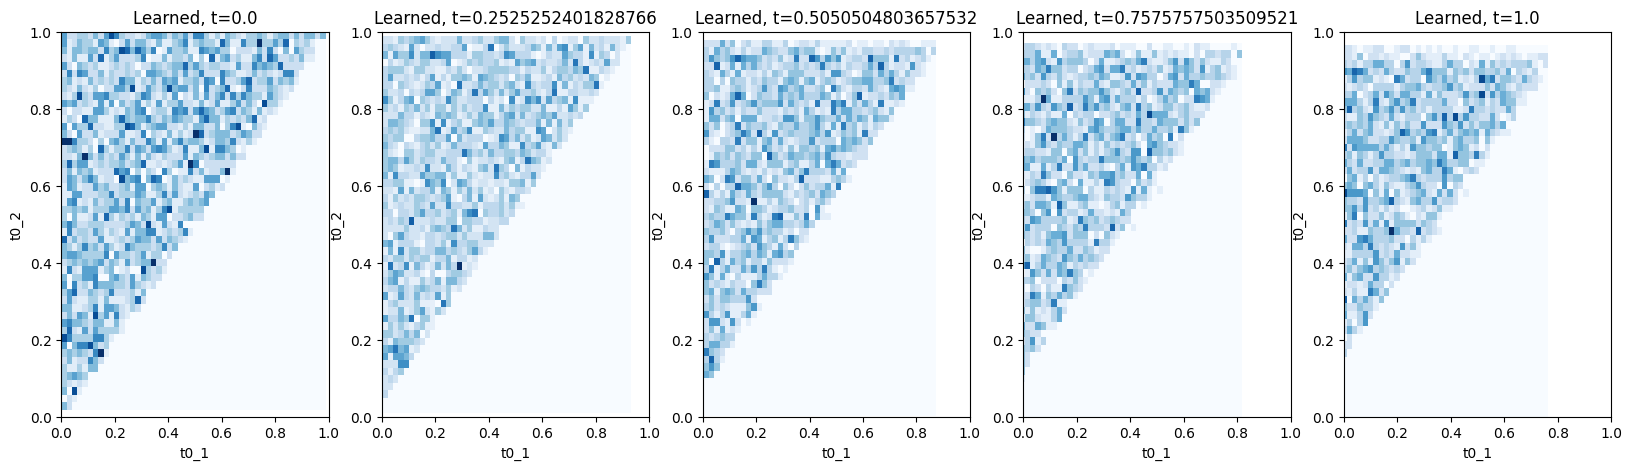

In [ ]:
###############################################
# Graph Marginals of Learned Vector Field #
###############################################
class LearnedVectorFieldODE():
    def __init__(self, net: MLPVectorField):
        self.net = net

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - x: (bs, dim)
            - t: (bs, dim)
        Returns:
            - u_t: (bs, dim)
        """
        return self.net(x, t, y)

num_samples = 4000
num_marginals = 5

ode = LearnedVectorFieldODE(linear_flow_model)
solver = EulerODESolver(ode)

ts = torch.linspace(0,1,100).to(device)
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))

x0 = path.p_simple.sample(num_samples)
simulations = torch.zeros((num_samples, 1000)).to(device)
prior = Prior()
N = 2

time = np.linspace(0, 1.0, 1000)
amp  = 25.0
t0   = 0.1
rise = 0.03
skew = 5
ybkg = 5.0

for idx in range(num_samples):
    # prior_sample = prior.sample(1)[0]
    # print(list(prior_sample.cpu().numpy()))
    burstparams = {
        't0'   : [0.1, 0.6], #list(prior_sample.cpu().numpy()),
        'amp'  : [amp, amp],
        'rise' : [rise, rise],
        'skew' : [skew, skew]
    }

    model = Model(
        time=time,
        ncomp=N, 
        burstparams=burstparams, 
        ybkg=ybkg
        )
    simulator = BurstSimulator(model)
    x_counts = simulator.simulate_burst()
    x_counts = torch.Tensor(x_counts)
    simulations[idx, :] = x_counts

# TODO: Need to adjust, since learned vector field takes label ("prompt") as input as well now
xts = solver.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1), y=simulations)
xts = xts[:,record_every_idxs,:]


plt.figure(figsize=(20, 5))

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(1, num_marginals, idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    
    plt.title(f"Learned, t={t}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()